# **mHEALTH - CNN (PyTorch)**

In [122]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

In [123]:
# 디바이스 설정 (GPU 사용 가능 여부 확인)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Data load

In [124]:
DATASET_PATH = "/content/drive/MyDrive/AI/Dataset/mHEALTH"

# Seed 고정

In [125]:
def set_seed(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Data Preprocessing & EDA

In [177]:
# 전처리 대상 칼럼 리스트 정의
SENSOR_COLUMNS = [
    'acc_chest_x', 'acc_chest_y', 'acc_chest_z',
    'ecg_1', 'ecg_2',
    'acc_left_ankle_x', 'acc_left_ankle_y', 'acc_left_ankle_z',
    'gyro_left_ankle_x', 'gyro_left_ankle_y', 'gyro_left_ankle_z',
    'mag_left_ankle_x', 'mag_left_ankle_y', 'mag_left_ankle_z',
    'acc_right_lower_arm_x', 'acc_right_lower_arm_y', 'acc_right_lower_arm_z',
    'gyro_right_lower_arm_x', 'gyro_right_lower_arm_y', 'gyro_right_lower_arm_z',
    'mag_right_lower_arm_x', 'mag_right_lower_arm_y', 'mag_right_lower_arm_z'
]
ALL_COLUMNS = SENSOR_COLUMNS + ['label']
SUBJECT_COLUMN = 'subject'

# 행동 매핑 딕셔너리
LABELS = {
    1: 'Standing still',
    2: 'Sitting and relaxing',
    3: 'Lying down',
    4: 'Walking',
    5: 'Climbing stairs',
    6: 'Waist bends forward',
    7: 'Frontal elevation of arms',
    8: 'Knees bending (crouching)',
    9: 'Cycling',
    10: 'Jogging',
    11: 'Running',
    12: 'Jump front & back'
}

현재 데이터셋 사양 지정

In [178]:
CHANNELS = len(SENSOR_COLUMNS)   # 센서 칼럼 수
CLASSES = len(LABELS)            # 출력 클래스 수
TIME_STEPS = 200
STEP = 40
BATCH_SIZE = 64                  # 한 번 학습할 때 볼 데이터 수
SEQ_LENGTH = 128                 # 윈도우 크기 타임스텝 수

데이터프레임 통합

In [179]:
# 로드한 폴더 내 모든 파일 가져오기
file_list = sorted(glob.glob(os.path.join(DATASET_PATH, "*.log")))
if not file_list:
    file_list = sorted(glob.glob(os.path.join(DATASET_PATH, "*.txt")))

data_frames = []

# 각 파일 전처리 (mHEALTH 데이터는 공백으로 구분되어 있음)
for i, file_path in enumerate(file_list):
    #header가 없으므로 None 지정 후, names에 칼럼명 넘기기.
    df_sub = pd.read_csv(file_path, sep=r'\s+', header=None, names=ALL_COLUMNS)
    df_sub['subject'] = i + 1    # 각 피험자에 subject(ID) 부여 (1~10)
    data_frames.append(df_sub)

# 하나의 데이터프레임으로 통합
df = pd.concat(data_frames, ignore_index=True)
print(f"원본 통합 데이터 형태: {df.shape}")

원본 통합 데이터 형태: (1215745, 25)


Label EDA

 라벨 0 제거 후 데이터 형태: (343195, 25)


/tmp/ipykernel_773/3864286622.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='activity_name', order=df['activity_name'].value_counts().index, palette='viridis')


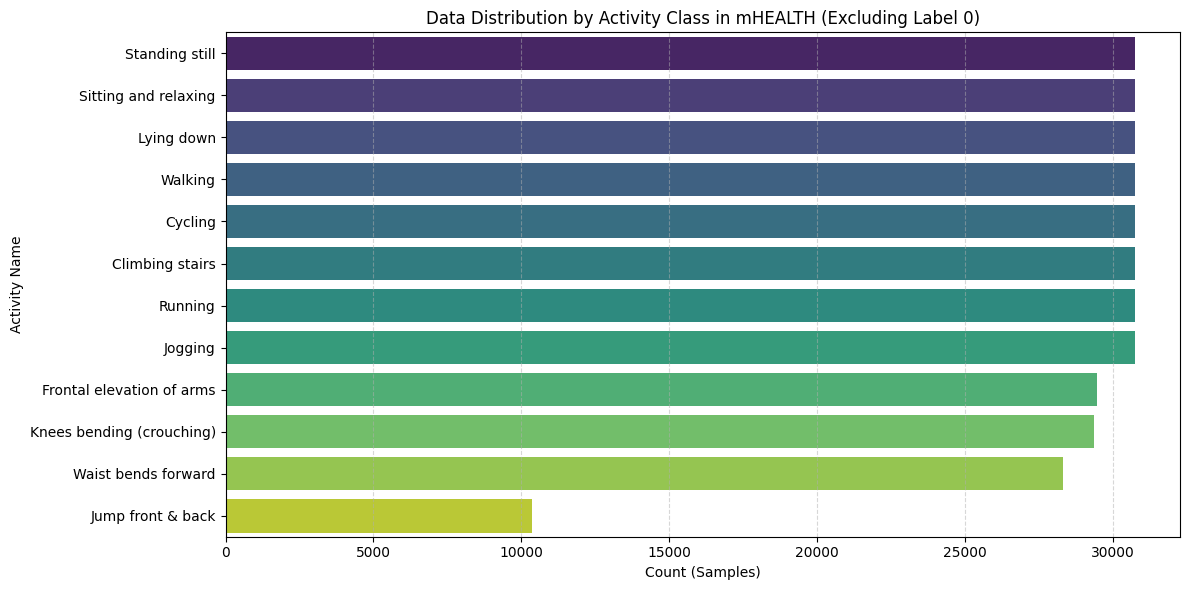

In [180]:
# 1. Null 의미하는 라벨 0번 제거
df = df[df['label'] != 0].reset_index(drop=True)
print(f" 라벨 0 제거 후 데이터 형태: {df.shape}")

# 2. LABELS 딕셔너리를 사용하여 한글/영문 행동명 매핑
df['activity_name'] = df['label'].map(LABELS)
df['activity_encoded'] = (df['label'] - 1).astype('int32')

# 3. LABELS 기준으로 클래스 불균형 검증용 EDA 시각화
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='activity_name', order=df['activity_name'].value_counts().index, palette='viridis')
plt.title('Data Distribution by Activity Class in mHEALTH (Excluding Label 0)')
plt.xlabel('Count (Samples)')
plt.ylabel('Activity Name')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Data Split (Subject 기준 분할)

In [181]:
df_train = df[df['subject'].isin([1, 2, 3, 4, 5, 6, 7, ])].reset_index(drop=True)
df_val   = df[df['subject'].isin([8])].reset_index(drop=True)
df_test = df[df['subject'].isin([9, 10])].reset_index(drop=True)

print(f"분할 후 Train 데이터 행 수: {df_train.shape[0]}")
print(f"분할 후 Val 데이터 행 수: {df_val.shape[0]}")
print(f"분할 후 Test 데이터 행 수: {df_test.shape[0]}")

분할 후 Train 데이터 행 수: 241256
분할 후 Val 데이터 행 수: 34253
분할 후 Test 데이터 행 수: 67686


Standard Scaling (Train에서 fit, Val/Test는 transform만)

In [182]:
scaler = StandardScaler()

# Train 데이터의 센서 값으로만 평균과 표준편차를 학습(fit)하고 적용(transform)
df_train[SENSOR_COLUMNS] = scaler.fit_transform(df_train[SENSOR_COLUMNS])

# Validation과 Test는 Train의 기준으로 변환(transform)만 수행 (Data Leakage 방지)
df_val[SENSOR_COLUMNS] = scaler.transform(df_val[SENSOR_COLUMNS])
df_test[SENSOR_COLUMNS] = scaler.transform(df_test[SENSOR_COLUMNS])

Segmentation (Sliding Window)

In [186]:
# 데이터가 수천 행 연속되어 있으므로, 윈도우 크기만큼 3차원으로 쪼개주는 함수
def create_dataset(df_split, time_steps=200, step=40):
    xs, ys = [], []

    if df_split.empty:
        return np.empty((0, time_steps, len(SENSOR_COLUMNS)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    df_split = df_split.copy()

    # 같은 subject 안에서 행동이 바뀌는 순간을 감지하여 segment_id 부여
    segment_id = df_split.groupby(SUBJECT_COLUMN)['activity_encoded'].transform(lambda s: s.ne(s.shift()).cumsum())
    df_split['segment'] = segment_id

    # subject와 segment 단위로 묶어서 윈도우 추출 (행동 섞임 방지)
    for _, segment in df_split.groupby([SUBJECT_COLUMN, 'segment'], sort=False):
        x_values = segment[SENSOR_COLUMNS].to_numpy(dtype=np.float32)
        y_value = int(segment['activity_encoded'].iloc[0])

        # 윈도우 크기보다 데이터가 짧으면 패스, 길면 윈도우 슬라이딩
        for i in range(0, len(x_values) - time_steps + 1, step):
            xs.append(x_values[i:i + time_steps])
            ys.append(y_value)

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)

# 설정값 적용 및 변환
x_train, y_train = create_dataset(df_train, TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val,   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test,  TIME_STEPS, STEP)

print(">> [변환 성공] 분할이 적용된 3차원 텐서 구조:")
print("-" * 60)
print("Train 라벨 범위:", np.min(y_train), "~", np.max(y_train))
print("클래스 개수:", len(np.unique(y_train)))
print("-" *60)
print(f"x_train shape: {x_train.shape} | y_train shape: {y_train.shape}")
print(f"x_val   shape: {x_val.shape}  | y_val   shape: {y_val.shape}")
print(f"x_test  shape: {x_test.shape}  | y_test  shape: {y_test.shape}")
print("-" *60)
# 값 분포가 정상적인지 확인 (특정 클래스에 몰려있는지 확인)
print("Train 라벨 분포:", np.bincount(y_train))
print("Val 라벨 분포:", np.bincount(y_val))
print("Test 라벨 분포:", np.bincount(y_test))


>> [변환 성공] 분할이 적용된 3차원 텐서 구조:
------------------------------------------------------------
Train 라벨 범위: 0 ~ 11
클래스 개수: 12
------------------------------------------------------------
x_train shape: (5636, 200, 23) | y_train shape: (5636,)
x_val   shape: (800, 200, 23)  | y_val   shape: (800,)
x_test  shape: (1579, 200, 23)  | y_test  shape: (1579,)
------------------------------------------------------------
Train 라벨 분포: [504 504 504 504 504 475 488 493 504 504 504 148]
Val 라벨 분포: [72 72 72 72 72 72 65 66 72 72 72 21]
Test 라벨 분포: [144 144 144 144 144 116 138 130 144 144 144  43]


클래스 불균형 보정

In [187]:
# 모델이 소수 클래스를 무시하지 않도록 방지
from sklearn.utils import class_weight

classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print('Class weights:', class_weights_dict)

Class weights: {np.int32(0): np.float64(0.9318783068783069), np.int32(1): np.float64(0.9318783068783069), np.int32(2): np.float64(0.9318783068783069), np.int32(3): np.float64(0.9318783068783069), np.int32(4): np.float64(0.9318783068783069), np.int32(5): np.float64(0.9887719298245614), np.int32(6): np.float64(0.962431693989071), np.int32(7): np.float64(0.9526707234617985), np.int32(8): np.float64(0.9318783068783069), np.int32(9): np.float64(0.9318783068783069), np.int32(10): np.float64(0.9318783068783069), np.int32(11): np.float64(3.1734234234234235)}


PyTorch 텐서 형태로 변환

In [189]:
X_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor   = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)

X_test_tensor  = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Model Building

1D Conv Block

In [190]:
class ConvBlock1D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int, dropout: float):
        super().__init__()
        # 입력 해상도가 급격히 줄어드는 것을 방지하기 위해 동일 패딩(Same Padding) 적용
        padding = kernel_size // 2

        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False  # BatchNorm을 바로 뒤에 사용하므로 편향(bias)은 제외
            ),
            nn.BatchNorm1d(out_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

Full Model

In [191]:
class Simple3LayerCNN(nn.Module):

    def __init__(self, in_channels: int = CHANNELS, num_classes: int = CLASSES, dropout: float = 0.20):
        super().__init__()

        # 1. 3개의 1D Conv 블록 쌓기
        # Block 1
        self.layer1 = ConvBlock1D(in_channels, 64, kernel_size=7, stride=1, dropout=dropout)

        # Block 2
        self.layer2 = ConvBlock1D(64, 96, kernel_size=5, stride=2, dropout=dropout)

        # Block 3
        self.layer3 = ConvBlock1D(96, 128, kernel_size=3, stride=2, dropout=dropout)

        # Adaptive Average Pooling과 Max Pooling을 모두 사용 후 가로로 결합(Concat)
        # 마지막 블록의 채널 수가 128이므로, 두 풀링 결과를 합쳐서 총 128 * 2 = 256 차원
        self.feature_dim = 128 * 2

        # 2. 분류기 헤드 (Classifier Head)
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim),
            nn.Linear(self.feature_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x의 형태: [Batch_Size, Channels(센서 칼럼수), Sequence_Length(128)]

        # Backbone (Feature Extraction)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # Global Pooling (시간 축 정보를 압축하여 고정된 크기의 벡터로 변환)
        avg_pool = F.adaptive_avg_pool1d(x, 1).squeeze(-1) # [Batch_Size, 128]
        max_pool = F.adaptive_max_pool1d(x, 1).squeeze(-1) # [Batch_Size, 128]

        # 두 풀링 결과를 채널(차원) 방향으로 결합 -> [Batch_Size, 256]
        features = torch.cat([avg_pool, max_pool], dim=1)

        # 최종 분류 수행 -> [Batch_Size, Num_Classes(6)]
        logits = self.classifier(features)
        return logits

모델 생성 및 구조 확인

In [192]:
if __name__ == "__main__":

    # 모델 선언
    model = Simple3LayerCNN(in_channels=CHANNELS, num_classes=CLASSES).to(device)

    # 모델 구조 트리 출력
    print("=== 모델 아키텍처 출력 ===")
    print(model)

    # 예측 수행
    dummy_input = torch.randn(BATCH_SIZE, CHANNELS, SEQ_LENGTH).to(device)
    dummy_out = model(dummy_input)

    print("\n" + "="*45)
    print("입력 데이터 (Batch, Channels, Length) : ", dummy_input.shape)
    print("출력 데이터 (Batch, Classes) : ", dummy_out.shape)
    print("="*45)

=== 모델 아키텍처 출력 ===
Simple3LayerCNN(
  (layer1): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(23, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (layer2): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(64, 96, kernel_size=(5,), stride=(2,), padding=(2,), bias=False)
      (1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (layer3): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(96, 128, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (classifier): Sequential(
 

Loss+Callbacks

In [196]:
# 전처리 단계의 '클래스 불균형 보정'을 Loss에 적용하기 위한 코드
# 딕셔너리의 가중치 값들을 클래스 순서대로 리스트화하여 Tensor로 변환
weights_list = [class_weights_dict[i] for i in sorted(class_weights_dict.keys())]
class_weights_tensor = torch.FloatTensor(weights_list).to(device)

# 1. 손실함수 및 옵티마이저 설정
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 2. 학습률 스케줄러 설정
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# 3. Callbacks 및 History 수동 연동 제어 변수 초기화
best_val_acc = 0.0
patience_counter = 0
early_stopping_patience = 15
checkpoint_path = 'best_mhealth.pt'
best_model_wts = copy.deepcopy(model.state_dict()) # 초기 상태 가중치 백업

# 4. History 저장을 위한 딕셔너리 정의
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

# Training & Validation

In [197]:
# --- 3. 학습 및 검증 루프 실행 (epochs=150) ---
epochs = 150
print("========== 모델 학습 및 Callbacks 루프 시작 ==========")

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # --------------------------------------
    # [Train Phase] - 학습 단계
    # --------------------------------------
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        # 데이터를 모델이 올라가 있는 장치(GPU/CPU)로 이동
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # [B, T, C] -> [B, C, T] 형태로 축을 변경
        batch_X = batch_X.transpose(1, 2)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # --------------------------------------
    # [Validation Phase] - 검증 단계
    # --------------------------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 역전파 연산 제외로 메모리 세이브 및 가속화
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            batch_X = batch_X.transpose(1, 2)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에포크 결과 출력
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --------------------------------------
    # --- 4. Callbacks 수동 연동 단계 ---
    # --------------------------------------
    # (1) ReduceLROnPlateau 스케줄러 업데이트 (검증 손실 기준 스케일링)
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"   >> Epoch {epoch}: val_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early Stopping 판단
    if patience_counter >= early_stopping_patience:
        print(f"\n★ Early stopping triggered at Epoch {epoch}. Restoring model weights from the end of the best epoch. ★")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

========== 모델 학습 및 Callbacks 루프 시작 ==========
Epoch 1/150 - 0.7s - loss: 0.4349 - accuracy: 0.8953 - val_loss: 0.2419 - val_accuracy: 0.8638 - lr: 0.001000
   >> Epoch 1: val_accuracy improved to 0.86384, saving model to best_mhealth.pt
Epoch 2/150 - 0.6s - loss: 0.0231 - accuracy: 0.9936 - val_loss: 0.2990 - val_accuracy: 0.8543 - lr: 0.001000
Epoch 3/150 - 0.6s - loss: 0.0126 - accuracy: 0.9956 - val_loss: 0.3018 - val_accuracy: 0.8911 - lr: 0.001000
   >> Epoch 3: val_accuracy improved to 0.89107, saving model to best_mhealth.pt
Epoch 4/150 - 0.6s - loss: 0.0163 - accuracy: 0.9959 - val_loss: 0.3412 - val_accuracy: 0.8866 - lr: 0.001000
Epoch 5/150 - 0.6s - loss: 0.0464 - accuracy: 0.9901 - val_loss: 0.0540 - val_accuracy: 0.9981 - lr: 0.001000
   >> Epoch 5: val_accuracy improved to 0.99810, saving model to best_mhealth.pt
Epoch 6/150 - 0.6s - loss: 0.0044 - accuracy: 0.9993 - val_loss: 0.0729 - val_accuracy: 0.9690 - lr: 0.001000
Epoch 7/150 - 0.6s - loss: 0.0036 - accuracy: 0.999

# Evaluation

📌 Best 기록 확인

In [198]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = Simple3LayerCNN(in_channels=CHANNELS, num_classes=CLASSES).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"▶ Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 1. 넘파이 배열을 텐서로 변환
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)

    # 만약 원본 데이터가 [샘플수, 200, 23] 구조라면,
    # 데이터로더에 넣기 전에 미리 [샘플수, 23, 200]으로 축을 전환
    if eval_tensor_X.shape[1] == 200: # 시퀀스 길이가 2번째 축에 있다면
        eval_tensor_X = eval_tensor_X.transpose(1, 2)

    # 2. 평가용 DataLoader 구성
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
print("\n======= 최고 기록 성능 평가 =======")

# x_train전체 데이터에 대해 평가
train_loss, train_acc = evaluate_pytorch_model(best_model, x_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

print("-" * 35)

# x_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, x_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")
print("=" * 35)

▶ Successfully loaded best model weights from best_mhealth.pt

======= 최고 기록 성능 평가 =======
Training accuracy: 100.00%
Training loss: 0.0016
-----------------------------------
Test accuracy: 99.81%
Test loss: 0.0542


📌 Classification Report

In [199]:
# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval()  # 평가 모드 활성화

# 예측용 DataLoader 구성 (x_test 전체를 안정적으로 처리하기 위해 배치 단위 구동)
test_tensor_X = torch.tensor(x_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device)  # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # [B, T, C] -> [B, C, T] 형태 변환
        batch_X = batch_X.transpose(1, 2)

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\n                Classification Report")
print("-" * 55)

# y_test는 이미 정수형 레이블이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


                Classification Report
-------------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       144
           1     0.9863    1.0000    0.9931       144
           2     1.0000    1.0000    1.0000       144
           3     1.0000    1.0000    1.0000       144
           4     0.9931    1.0000    0.9965       144
           5     1.0000    1.0000    1.0000       116
           6     1.0000    1.0000    1.0000       138
           7     1.0000    0.9923    0.9961       130
           8     1.0000    0.9861    0.9930       144
           9     1.0000    1.0000    1.0000       144
          10     1.0000    1.0000    1.0000       144
          11     1.0000    1.0000    1.0000        43

    accuracy                         0.9981      1579
   macro avg     0.9983    0.9982    0.9982      1579
weighted avg     0.9981    0.9981    0.9981      1579



📌 지표(Metrics) 계산 및 효율성(FLOPs/추론시간) 측정

In [200]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=b281c6ab1e5f67c62f36b6c4191825bd7529c1b11733dd3f8e6732102dcbbfbc
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=2001d7549beff5565188338a7f0c621edc75b261ed2db0498cea4d7ccbe5618c
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [208]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from fvcore.nn import FlopCountAnalysis

def evaluate_model_efficiency_and_metrics_fixed(model, test_loader, device, input_size=(1, 23, 200)):
    model.eval()

    # [1] 모델 복잡도 측정
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    dummy_input = torch.randn(*input_size).to(device)
    flops_analyzer = FlopCountAnalysis(model, dummy_input)
    flops_analyzer.unsupported_ops_warnings(False)
    total_flops = flops_analyzer.total()

    # [2] 정량 지표 및 추론 시간 측정
    all_preds = []
    all_targets = []
    inference_times = []

    with torch.no_grad():
        # 데이터로더가 1개(X만)를 주든, 2개(X, y)를 주든 상관없이 받음.
        for batch in test_loader:
            if isinstance(batch, (list, tuple)) and len(batch) >= 2:
                batch_X, batch_y = batch[0], batch[1]
            else:
                batch_X = batch[0] if isinstance(batch, (list, tuple)) else batch
                batch_y = None

            # 입력 데이터 장치 이동 및 텐서 변환
            if isinstance(batch_X, torch.Tensor):
                inputs = batch_X.to(device)
            else:
                inputs = torch.tensor(batch_X, dtype=torch.float32).to(device)

            # [축 전환] [B, T, C] -> [B, C, T] 형태 변환
            inputs = inputs.transpose(1, 2)

            # 순수 추론 시간 측정
            start_time = time.time()
            outputs = model(inputs)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.time()

            # 개당 추론 시간 계산
            inference_times.append((end_time - start_time) * 1000 / inputs.size(0))

            # 예측값 추출
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())

            # 정답 라벨이 존재할 때만 축적
            if batch_y is not None:
                if len(batch_y.shape) > 1 and batch_y.shape[1] > 1: # 원-핫 인코딩 대응
                    true_labels = torch.argmax(batch_y, dim=1)
                else:
                    true_labels = batch_y
                all_targets.extend(true_labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    avg_inference_time = np.mean(inference_times)

    # [3] 결과 출력 분기
    print("="*50)
    print(f"🥇 Metrics & Efficiency Evaluation")
    print("="*50)
    print(f"Parameters   : {total_params / 1e6:.4f} M")
    print(f"FLOPs        : {total_flops / 1e6:.4f} M")
    print(f"Inference    : {avg_inference_time:.3f} ms/sample")

    # 라벨이 같이 제공된 데이터로더(예: val_loader)인 경우에만 정확도 지표 출력.
    if len(all_targets) > 0:
        accuracy = accuracy_score(all_targets, all_preds) * 100
        precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
        print(f"Accuracy     : {accuracy:.2f} %")
        print(f"F1 Score     : {f1:.4f}")
        print(f"Recall       : {recall:.4f}")
        print(f"Precision    : {precision:.4f}")
        print("="*50)
        return all_targets, all_preds
    else:
        print("[안내] 데이터로더에 정답 라벨(y)이 없어 정확도 관련 지표 측정은 제외하고 모델 정보 및 속도만 측정했습니다.")
        print("="*50)
        return None, all_preds

# 함수 호출 및 출력
targets, test_preds = evaluate_model_efficiency_and_metrics_fixed(
    model=best_model,
    test_loader=val_loader, # 검증 데이터로더 전달
    device=device,
    input_size=(1, CHANNELS, TIME_STEPS)
)

🥇 Metrics & Efficiency Evaluation
Parameters   : 0.1134 M
FLOPs        : 7.0692 M
Inference    : 0.017 ms/sample
Accuracy     : 99.81 %
F1 Score     : 0.9982
Recall       : 0.9982
Precision    : 0.9983


📌 Loss / Accuracy 그래프

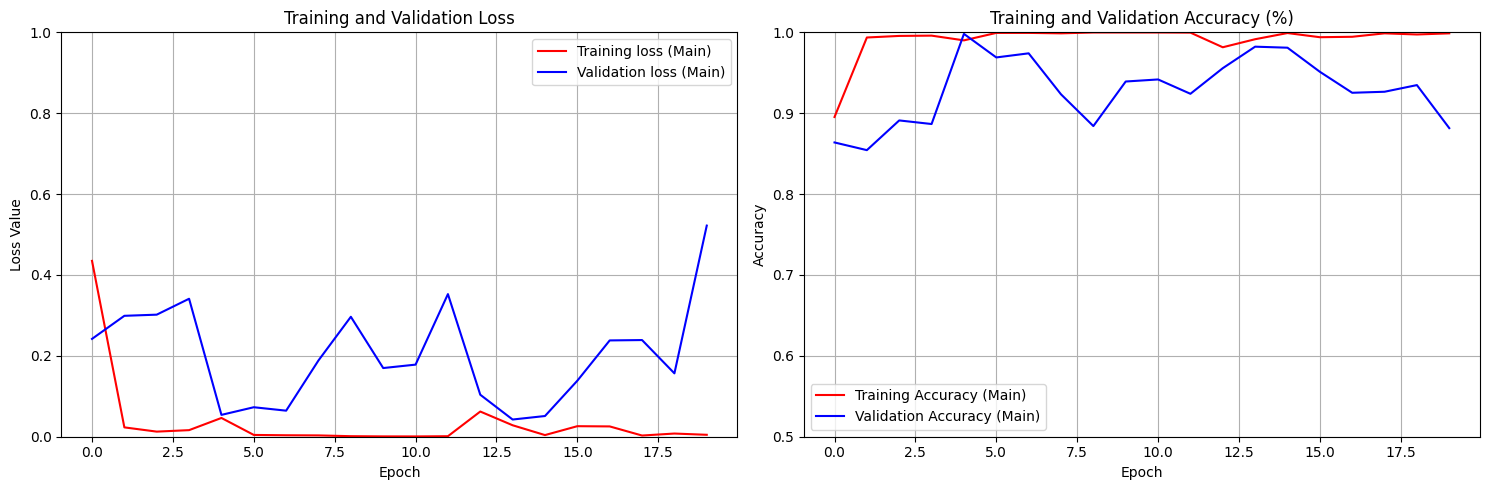

In [211]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
# 파이토치 루프에서 직접 채워넣은 history 딕셔너리를 활용
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.ylim([0.0, 1.0]) # 데이터셋 특성에 맞춰 X축 범위 지정
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

📌Embedding Space t-SNE

데이터셋으로부터 특징 벡터 및 CNN 잠재공간 임베딩을 추출하고 있습니다...
▶ 입력 공간 데이터 형태(Flattened) : (1579, 4600)
▶ 잠재 공간 데이터 형태 : (1579, 256)

입력 공간(Raw) t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


잠재 공간(CNN) t-SNE 차원 축소 진행 중...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


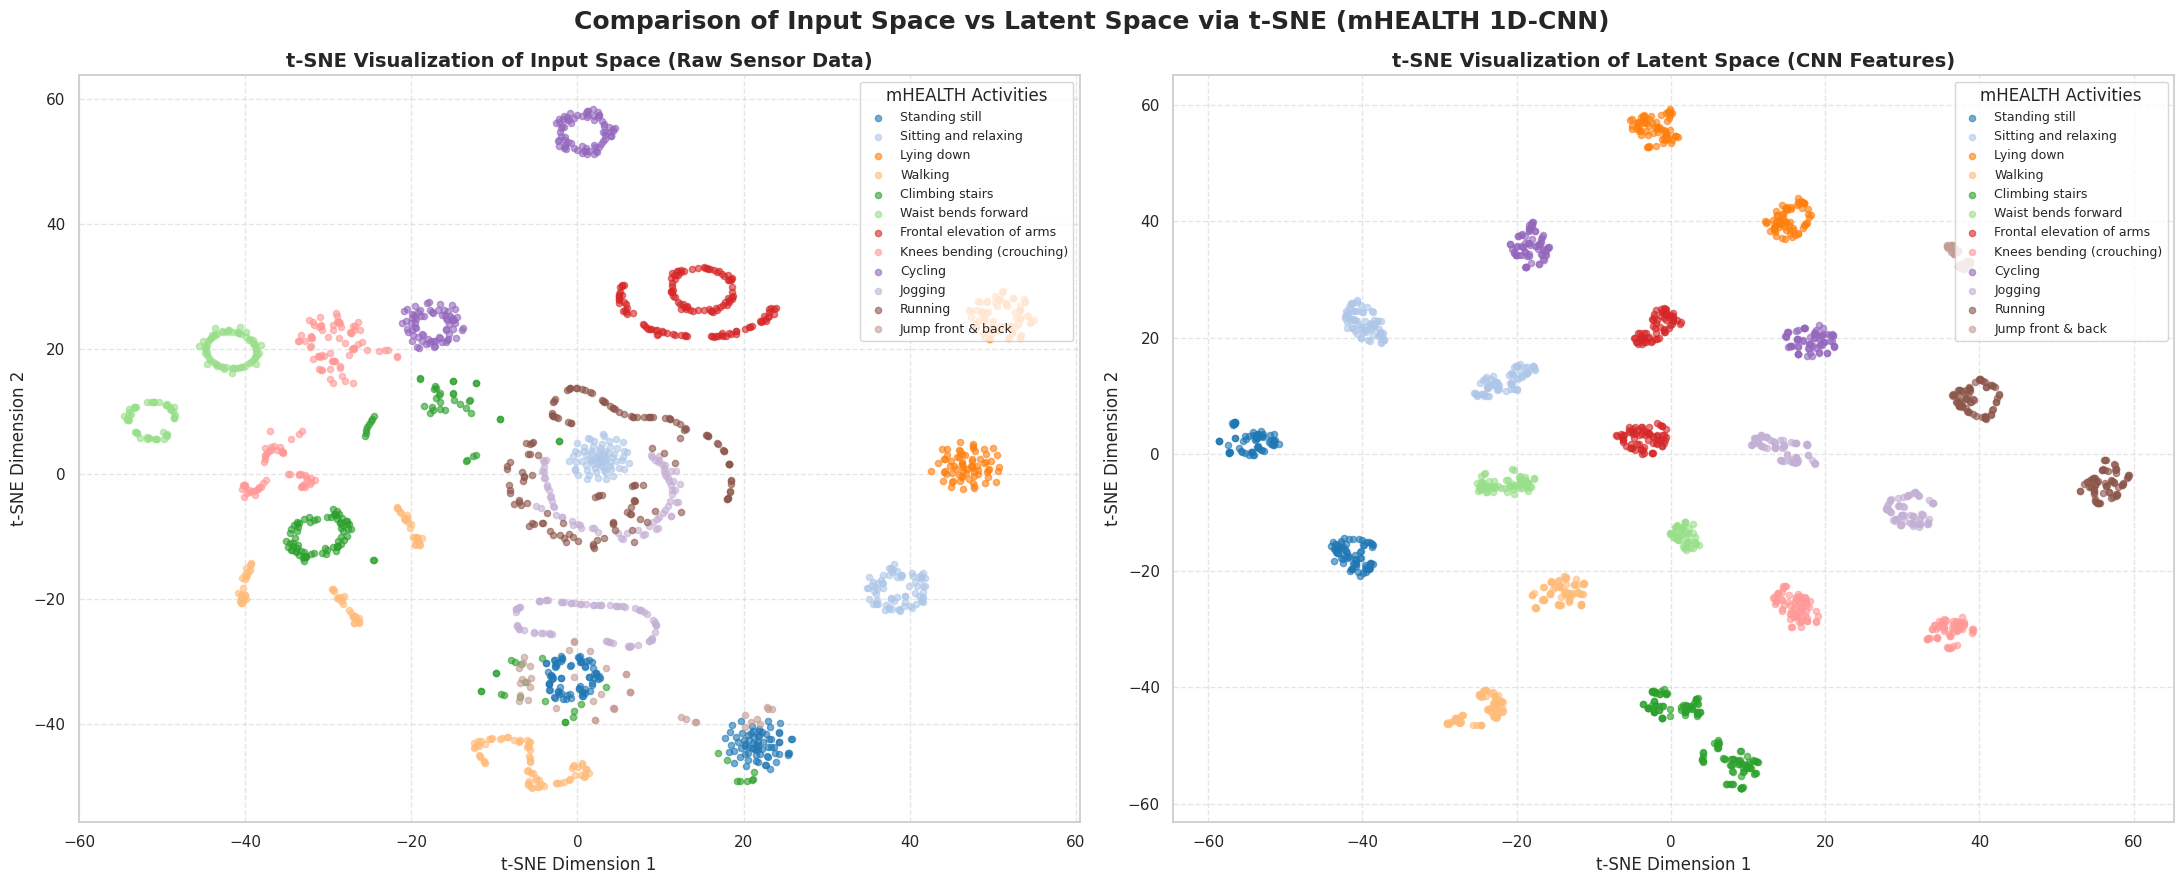

In [213]:
from sklearn.manifold import TSNE

def visualize_dual_tsne_mhealth_cnn(model, data_loader, device):
    model.eval()

    input_features = []
    latent_embeddings = []
    labels = []

    print("데이터셋으로부터 특징 벡터 및 CNN 잠재공간 임베딩을 추출하고 있습니다...")
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            # 1-1. 입력 공간 데이터 수집 (Shape: [Batch, Length * Channel] 형태로 Flatten)
            # 입력 데이터 장치 이동 전 넘파이 변환을 위해 복사본 flatten
            inputs_flatten = batch_X.view(batch_X.size(0), -1).cpu().numpy()
            input_features.append(inputs_flatten)

            # 1-2. 잠재 공간 임베딩 수집 (Simple3LayerCNN 아키텍처 포워드 추적)
            # PyTorch 1D Conv 입력 조건 맞추기 [B, T, C] -> [B, C, T]
            batch_X_conv = batch_X.to(device).transpose(1, 2)

            # 모델의 Backbone 연산 수행
            x = model.layer1(batch_X_conv)     # Block 1
            x = model.layer2(x)                # Block 2
            x = model.layer3(x)                # Block 3

            # 모델 정의와 동일한 Global Pooling 결합 메커니즘 적용
            avg_pool = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
            max_pool = F.adaptive_max_pool1d(x, 1).squeeze(-1)

            # 최종 분류기 직전의 256차원 결합 특징 벡터 추출 -> [Batch, 256]
            latent_vector = torch.cat([avg_pool, max_pool], dim=1)
            latent_embeddings.append(latent_vector.cpu().numpy())

            # 1-3. 라벨 처리 (인코딩된 0~11 정수 라벨 수집)
            if len(batch_y.shape) > 1 and batch_y.shape[1] > 1:
                labels.append(torch.argmax(batch_y, dim=1).cpu().numpy())
            else:
                labels.append(batch_y.cpu().numpy())

    # 리스트에 담긴 배치 데이터를 하나로 결합
    input_features = np.concatenate(input_features, axis=0)
    latent_embeddings = np.concatenate(latent_embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"▶ 입력 공간 데이터 형태(Flattened) : {input_features.shape}")
    print(f"▶ 잠재 공간 데이터 형태 : {latent_embeddings.shape}")

    # 2. t-SNE를 이용한 차원 축소 (각각 2차원으로 축소)
    print("\n입력 공간(Raw) t-SNE 차원 축소 진행 중...")
    tsne_input = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_input_results = tsne_input.fit_transform(input_features)

    print("잠재 공간(CNN) t-SNE 차원 축소 진행 중...")
    tsne_latent = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    tsne_latent_results = tsne_latent.fit_transform(latent_embeddings)

    # 3. Matplotlib 1x2 서브플롯 시각화
    sns.set_theme(style='whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

    # mHEALTH LABELS 딕셔너리에서 정렬된 순서대로 행동명 추출 (0~11에 대응되도록 정렬)
    # 인코딩할 때 label - 1을 해주었으므로 key-1 순서대로 정렬
    class_names = [LABELS[k] for k in sorted(LABELS.keys())]
    num_classes = len(class_names)

    # 12개 클래스를 뚜렷하게 구분하기 위한 고유 팔레트 생성
    colors = sns.color_palette("tab20", num_classes)

    # 두 그래프 모두에 클래스별 데이터 플롯
    for i in range(num_classes):
        indices = np.where(labels == i)

        # [왼쪽] 입력 공간 시각화
        ax1.scatter(
            tsne_input_results[indices, 0],
            tsne_input_results[indices, 1],
            label=class_names[i],
            color=colors[i],
            alpha=0.6,
            s=20
        )

        # [오른쪽] 잠재 공간 시각화
        ax2.scatter(
            tsne_latent_results[indices, 0],
            tsne_latent_results[indices, 1],
            label=class_names[i],
            color=colors[i],
            alpha=0.6,
            s=20
        )

    # 왼쪽 Plot(입력 공간) 스타일링
    ax1.set_title('t-SNE Visualization of Input Space (Raw Sensor Data)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('t-SNE Dimension 1')
    ax1.set_ylabel('t-SNE Dimension 2')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), title="mHEALTH Activities", fontsize=9)

    # 오른쪽 Plot(잠재 공간) 스타일링
    ax2.set_title('t-SNE Visualization of Latent Space (CNN Features)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('t-SNE Dimension 1')
    ax2.set_ylabel('t-SNE Dimension 2')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), title="mHEALTH Activities", fontsize=9)

    plt.suptitle('Comparison of Input Space vs Latent Space via t-SNE (mHEALTH 1D-CNN)', fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# --- 시각화 함수 호출 ---
visualize_dual_tsne_mhealth_cnn(best_model, val_loader, device)

📌 혼동 행렬 (Confusion Matrix)

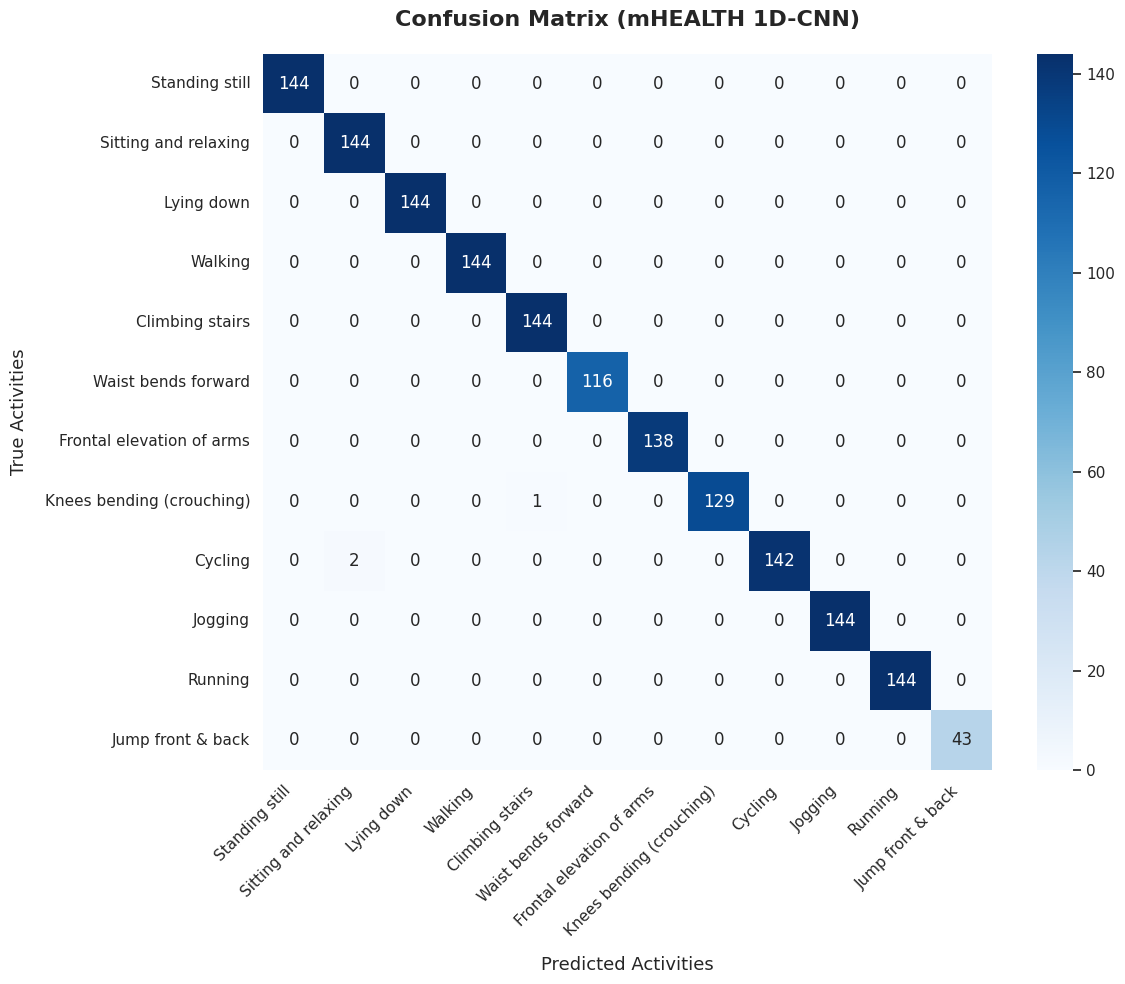

In [215]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10)) # 클래스가 갯수에 맞게 크기 수정
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True)

# --- 3. 축 레이블 및 타이틀 설정 ---
# LABELS 딕셔너리에서 인덱스 순서대로 정확한 액티비티 명칭 추출
class_names = [LABELS[k] for k in sorted(LABELS.keys())]

plt.title('Confusion Matrix (mHEALTH 1D-CNN)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Activities', fontsize=13, labelpad=12)
plt.ylabel('True Activities', fontsize=13, labelpad=12)

# 추출한 클래스명으로 X축, Y축 레이블 동적 매핑
plt.xticks(np.arange(len(class_names)) + 0.5, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(np.arange(len(class_names)) + 0.5, class_names, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()